In [ ]:
!pip install pandas scikit-learn openpyxl

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fraud_ml_dataset.xlsx to fraud_ml_dataset (1).xlsx


In [ ]:
import os

print(os.listdir())

['.config', 'fraud_ml_dataset (1).xlsx', 'fraud_ml_dataset.xlsx', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_excel("fraud_ml_dataset.xlsx")

df.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Type,Transaction Frequency,Risk Score,Fraud Flag
0,T001,C001,850000,Transfer,High,92,Yes
1,T002,C002,200000,Deposit,Low,25,No
2,T003,C003,950000,Withdrawal,High,89,Yes
3,T004,C004,150000,Deposit,Low,30,No
4,T005,C005,780000,Transfer,High,85,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction ID         20 non-null     object
 1   Customer ID            20 non-null     object
 2   Transaction Amount     20 non-null     int64 
 3   Transaction Type       20 non-null     object
 4   Transaction Frequency  20 non-null     object
 5   Risk Score             20 non-null     int64 
 6   Fraud Flag             20 non-null     object
dtypes: int64(2), object(5)
memory usage: 1.2+ KB


In [ ]:
print(df.columns)

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Type', 'Transaction Frequency', 'Risk Score',
       'Fraud Flag'],
      dtype='object')


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Transaction Type"] = encoder.fit_transform(df["Transaction Type"])
df["Transaction Frequency"] = encoder.fit_transform(df["Transaction Frequency"])
df["Fraud Flag"] = encoder.fit_transform(df["Fraud Flag"])

df.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Type,Transaction Frequency,Risk Score,Fraud Flag
0,T001,C001,850000,1,0,92,1
1,T002,C002,200000,0,1,25,0
2,T003,C003,950000,2,0,89,1
3,T004,C004,150000,0,1,30,0
4,T005,C005,780000,1,0,85,1


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Features
X = df[[
    "Transaction Amount",
    "Transaction Type",
    "Transaction Frequency",
    "Risk Score"
]]

# Target
y = df["Fraud Flag"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 1.0

Confusion Matrix:
[[4 0]
 [0 2]]


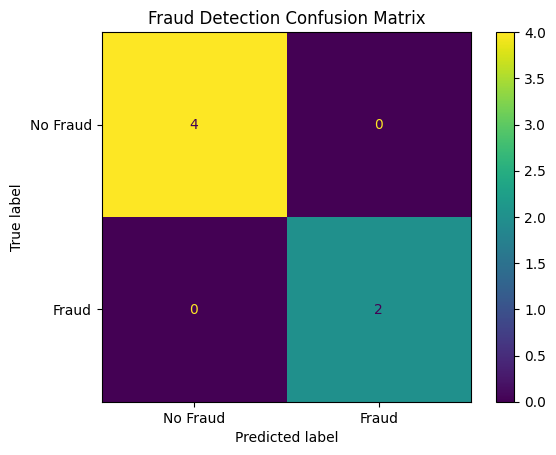

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Fraud", "Fraud"]
)

disp.plot()

plt.title("Fraud Detection Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [17]:
from google.colab import files

files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [23]:
from google.colab import files

files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import joblib

model = joblib.load("fraud_detection_model.pkl")

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
